# Post-Digitization ECG Refinement — cDDPM v2
**Real PhysioNet Data | 500 samples | 1250-point signals | Ensemble Digitizer**

### What changed from v1
| | v1 (old) | v2 (this notebook) |
|---|---|---|
| Samples | 120 | 500 |
| Signal length | 2500 (2× duplicated) | 1250 (real) |
| Mean cosine | 0.884 | 0.9735 |
| Normalization | independent (erases amplitude error) | shared clean scale |
| Digitizer | color sweep only | ensemble (sweep + NN) |
| Result | −2.7% MSE | ??? |

In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from numpy.linalg import norm
from scipy.spatial.distance import cosine as scipy_cosine

torch.manual_seed(42)
np.random.seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Running on: {DEVICE}')

Running on: cuda


Loaded: noisy (500, 1250)  clean (500, 1250)
NaNs   — noisy: 0  clean: 0

Cosine similarity — mean: 0.9735  std: 0.0236  min: 0.8699
Baseline MSE (input vs clean): 0.01207


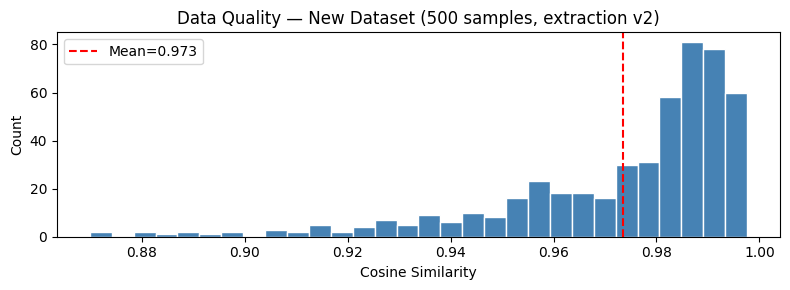

In [2]:
# ============================================================
# CELL 2 — Load data
# ============================================================
# ---- CHANGE PATHS IF NEEDED ----
FILE_NOISY = 'noisynew2.npy'
FILE_CLEAN = 'cleannew2.npy'
FILE_META  = 'metadata2.csv'
# --------------------------------

noisy_raw = np.load(FILE_NOISY).astype(np.float32)  # (500, 1250)
clean_raw = np.load(FILE_CLEAN).astype(np.float32)  # (500, 1250)
meta      = pd.read_csv(FILE_META)

print(f'Loaded: noisy {noisy_raw.shape}  clean {clean_raw.shape}')
print(f'NaNs   — noisy: {np.isnan(noisy_raw).sum()}  clean: {np.isnan(clean_raw).sum()}')

# Per-sample cosine similarity (already filtered >= 0.85 at extraction time)
cosines = np.array([
    np.dot(noisy_raw[i], clean_raw[i]) /
    (norm(noisy_raw[i]) * norm(clean_raw[i]) + 1e-8)
    for i in range(len(noisy_raw))
])

print(f'\nCosine similarity — mean: {cosines.mean():.4f}  '
      f'std: {cosines.std():.4f}  min: {cosines.min():.4f}')

# Baseline MSE (before any refinement)
baseline_mse = np.mean((noisy_raw - clean_raw)**2)
print(f'Baseline MSE (input vs clean): {baseline_mse:.5f}')

# Cosine distribution plot
plt.figure(figsize=(8, 3))
plt.hist(cosines, bins=30, color='steelblue', edgecolor='white')
plt.axvline(cosines.mean(), color='red', linestyle='--',
            label=f'Mean={cosines.mean():.3f}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Data Quality — New Dataset (500 samples, extraction v2)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_data_quality_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# ============================================================
# CELL 3 — Train / Validation split + DataLoaders
# ============================================================
# 80 / 20 split — lets us monitor generalization during training
N          = len(noisy_raw)
N_TRAIN    = int(0.8 * N)   # 400
N_VAL      = N - N_TRAIN    # 100

noisy_t = torch.FloatTensor(noisy_raw).unsqueeze(1)  # (500, 1, 1250)
clean_t = torch.FloatTensor(clean_raw).unsqueeze(1)

dataset     = TensorDataset(noisy_t, clean_t)
train_set, val_set = random_split(
    dataset, [N_TRAIN, N_VAL],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)

print(f'Train: {N_TRAIN} samples | Val: {N_VAL} samples')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 400 samples | Val: 100 samples
Train batches: 13 | Val batches: 4


In [4]:
# ============================================================
# CELL 4 — Model (cDDPM 1D UNet)
# ============================================================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device   = t.device
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)


class ResBlock1D(nn.Module):
    """Residual conv block with time embedding injection."""
    def __init__(self, channels, t_channels):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, channels)
        self.conv1  = nn.Conv1d(channels, channels, 3, padding=1)
        self.t_proj = nn.Linear(t_channels, channels)
        self.norm2  = nn.GroupNorm(8, channels)
        self.conv2  = nn.Conv1d(channels, channels, 3, padding=1)
        self.act    = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = h + self.t_proj(t_emb).unsqueeze(-1)
        h = self.act(self.norm2(h))
        h = self.conv2(h)
        return x + h


class DiffusionUNet1D(nn.Module):
    """
    Conditional 1D UNet for ECG post-digitization refinement.
    Input : x_t (noisy clean at timestep t) + condition (digitized signal)
    Output: predicted noise

    Improvements over v1:
    - GroupNorm instead of no norm (more stable on small batches)
    - Residual blocks (skip connections within encoder/decoder)
    - SiLU activation (smoother gradients than ReLU)
    - Deeper bottleneck
    """
    def __init__(self, base_ch=128, t_dim=128):
        super().__init__()
        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(64),
            nn.Linear(64, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        # Encoder  (input = x_t + condition = 2 channels)
        self.enc_in = nn.Conv1d(2, base_ch, 3, padding=1)
        self.enc1   = ResBlock1D(base_ch,   t_dim)          # (B, 128, 1250)
        self.down1  = nn.Conv1d(base_ch, base_ch*2, 3, stride=2, padding=1)  # -> 625
        self.enc2   = ResBlock1D(base_ch*2, t_dim)          # (B, 256, 625)
        self.down2  = nn.Conv1d(base_ch*2, base_ch*4, 3, stride=2, padding=1) # -> 313
        self.enc3   = ResBlock1D(base_ch*4, t_dim)          # (B, 512, 313)
        # Bottleneck
        self.mid1   = ResBlock1D(base_ch*4, t_dim)
        self.mid2   = ResBlock1D(base_ch*4, t_dim)
        # Decoder
        self.up2    = nn.Upsample(scale_factor=2, mode='linear', align_corners=False)
        self.dec3   = nn.Conv1d(base_ch*4 + base_ch*2, base_ch*2, 3, padding=1)
        self.res3   = ResBlock1D(base_ch*2, t_dim)
        self.up1    = nn.Upsample(scale_factor=2, mode='linear', align_corners=False)
        self.dec2   = nn.Conv1d(base_ch*2 + base_ch, base_ch, 3, padding=1)
        self.res2   = ResBlock1D(base_ch, t_dim)
        self.out    = nn.Conv1d(base_ch, 1, 1)

    def forward(self, x, cond, t):
        t_emb = self.time_mlp(t)                          # (B, t_dim)
        h     = torch.cat([x, cond], dim=1)               # (B, 2, L)
        # Encode
        e1    = self.enc1(self.enc_in(h), t_emb)          # (B, 128, L)
        e2    = self.enc2(self.down1(e1), t_emb)          # (B, 256, L/2)
        e3    = self.enc3(self.down2(e2), t_emb)          # (B, 512, L/4)
        # Bottleneck
        m     = self.mid2(self.mid1(e3, t_emb), t_emb)   # (B, 512, L/4)
        # Decode
        d3    = self.up2(m)                                # (B, 512, L/2)
        if d3.size(2) != e2.size(2): d3 = d3[:, :, :e2.size(2)]
        d3    = self.res3(self.dec3(torch.cat([d3, e2], 1)), t_emb)
        d2    = self.up1(d3)                               # (B, 256, L)
        if d2.size(2) != e1.size(2): d2 = d2[:, :, :e1.size(2)]
        d2    = self.res2(self.dec2(torch.cat([d2, e1], 1)), t_emb)
        return self.out(d2)


model       = DiffusionUNet1D(base_ch=128, t_dim=128).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model ready.  Parameters: {total_params:,}')

# Quick shape check
with torch.no_grad():
    _x   = torch.zeros(2, 1, 1250).to(DEVICE)
    _t   = torch.zeros(2, dtype=torch.long).to(DEVICE)
    _out = model(_x, _x, _t)
    print(f'Output shape check: {_out.shape}  (expected [2, 1, 1250])')

Model ready.  Parameters: 7,268,481
Output shape check: torch.Size([2, 1, 1250])  (expected [2, 1, 1250])


In [5]:
# ============================================================
# CELL 5 — Diffusion schedule
# ============================================================
T      = 200
betas  = torch.linspace(0.0001, 0.02, T).to(DEVICE)
alphas = 1.0 - betas
alphas_cumprod      = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0]).to(DEVICE), alphas_cumprod[:-1]])
sqrt_acp            = torch.sqrt(alphas_cumprod)
sqrt_one_minus_acp  = torch.sqrt(1.0 - alphas_cumprod)

def gather(arr, t, x_shape):
    out = arr.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

print(f'Schedule: T={T}, beta [{betas[0]:.5f} → {betas[-1]:.4f}]')

Schedule: T=200, beta [0.00010 → 0.0200]


Training: 200 epochs | 400 train / 100 val samples

Epoch  50/200 | train: 0.02539 | val: 0.05038 | best_val: 0.02061
Epoch 100/200 | train: 0.02384 | val: 0.02404 | best_val: 0.01639
Epoch 150/200 | train: 0.02066 | val: 0.02510 | best_val: 0.01503
Epoch 200/200 | train: 0.01785 | val: 0.03058 | best_val: 0.01348

Training done. Best val loss: 0.01348


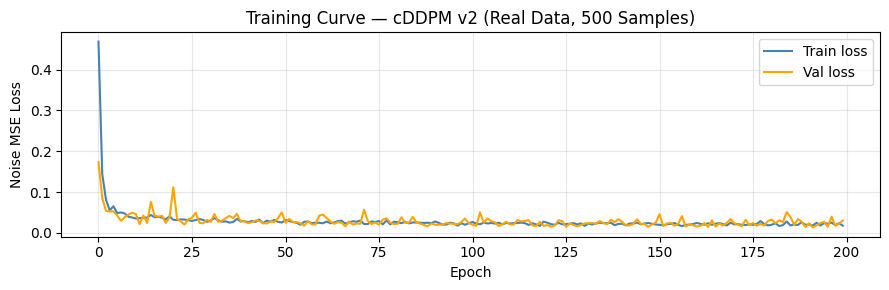

In [6]:
# ============================================================
# CELL 6 — Training
# ============================================================
EPOCHS    = 200
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f'Training: {EPOCHS} epochs | {N_TRAIN} train / {N_VAL} val samples\n')
model.train()

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    t_loss = 0.0
    for bn, cv in train_loader:
        bn, cv = bn.to(DEVICE), cv.to(DEVICE)
        t  = torch.randint(0, T, (cv.shape[0],), device=DEVICE).long()
        eps = torch.randn_like(cv)
        x_t = gather(sqrt_acp, t, cv.shape) * cv + \
              gather(sqrt_one_minus_acp, t, cv.shape) * eps
        loss = criterion(model(x_t, bn, t), eps)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()

    # --- Validate ---
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for bn, cv in val_loader:
            bn, cv = bn.to(DEVICE), cv.to(DEVICE)
            t  = torch.randint(0, T, (cv.shape[0],), device=DEVICE).long()
            eps = torch.randn_like(cv)
            x_t = gather(sqrt_acp, t, cv.shape) * cv + \
                  gather(sqrt_one_minus_acp, t, cv.shape) * eps
            v_loss += criterion(model(x_t, bn, t), eps).item()

    avg_t = t_loss / len(train_loader)
    avg_v = v_loss / len(val_loader)
    train_losses.append(avg_t)
    val_losses.append(avg_v)
    scheduler.step()

    # Save best model
    if avg_v < best_val_loss:
        best_val_loss = avg_v
        torch.save(model.state_dict(), 'dm_v2_best.pt')

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:>3}/{EPOCHS} | train: {avg_t:.5f} | val: {avg_v:.5f} '
              f'| best_val: {best_val_loss:.5f}')

# Load best weights for evaluation
model.load_state_dict(torch.load('dm_v2_best.pt', map_location=DEVICE))
print(f'\nTraining done. Best val loss: {best_val_loss:.5f}')

# Plot
plt.figure(figsize=(9, 3))
plt.plot(train_losses, label='Train loss', color='steelblue')
plt.plot(val_losses,   label='Val loss',   color='orange')
plt.xlabel('Epoch')
plt.ylabel('Noise MSE Loss')
plt.title('Training Curve — cDDPM v2 (Real Data, 500 Samples)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_train_curve_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 7 — Refinement sampler
# ============================================================
@torch.no_grad()
def refine(model, noisy_cond, t_start=30):
    """
    Partial reverse diffusion starting at t_start.
    t_start=30 means we only denoise the last 15% of the schedule —
    appropriate for refinement (not full generation from pure noise).
    """
    model.eval()
    cond = noisy_cond.to(DEVICE)           # (1, 1, 1250)

    # Start: encode the noisy condition into the diffusion trajectory
    t_b = torch.full((1,), t_start, device=DEVICE, dtype=torch.long)
    img = gather(sqrt_acp, t_b, cond.shape) * cond + \
          gather(sqrt_one_minus_acp, t_b, cond.shape) * torch.randn_like(cond)

    for i in range(t_start, -1, -1):
        t = torch.full((1,), i, device=DEVICE, dtype=torch.long)

        beta_t    = gather(betas, t, img.shape)
        sqrt_1m   = gather(sqrt_one_minus_acp, t, img.shape)
        sqrt_a    = gather(sqrt_acp, t, img.shape)
        acp_t     = gather(alphas_cumprod, t, img.shape)
        acp_prev  = gather(alphas_cumprod_prev, t, img.shape)
        alpha_t   = gather(alphas, t, img.shape)

        # Predict noise → estimate x0
        eps_pred = model(img, cond, t)
        x0_pred  = (img - sqrt_1m * eps_pred) / (sqrt_a + 1e-8)
        x0_pred  = torch.clamp(x0_pred, -1.5, 1.5)  # wider clamp for real data

        # Posterior mean
        coef1 = beta_t * torch.sqrt(acp_prev) / (1.0 - acp_t + 1e-8)
        coef2 = (1.0 - acp_prev) * torch.sqrt(alpha_t) / (1.0 - acp_t + 1e-8)
        mean  = coef1 * x0_pred + coef2 * img

        img = mean if i == 0 else mean + 0.5 * torch.sqrt(beta_t) * torch.randn_like(img)

    return img


print('Sampler ready.')

Sampler ready.


In [8]:
# ============================================================
# CELL 8 — Metrics helper
# ============================================================
def metrics(sig, ref):
    """Returns (mse, mae, snr_db, prd_pct, cosine_sim)."""
    s  = sig.flatten().astype(np.float64)
    r  = ref.flatten().astype(np.float64)
    eps = 1e-10
    mse = np.mean((r - s) ** 2)
    mae = np.mean(np.abs(r - s))
    sp  = np.sum(r ** 2)
    np_ = np.sum((r - s) ** 2)
    snr = 10 * np.log10(sp / (np_ + eps)) if sp > eps else 0.0
    prd = np.sqrt(np_ / (sp + eps)) * 100.0
    n1, n2 = norm(r), norm(s)
    cos = np.dot(r, s) / (n1 * n2 + eps) if (n1 > eps and n2 > eps) else 0.0
    return mse, mae, snr, prd, cos

print('Metrics helper ready.')

Metrics helper ready.


In [9]:
# ============================================================
# CELL 9 — Full evaluation (all 500 samples)
# ============================================================
REFINE_STEPS = 30

keys = ['mse', 'mae', 'snr', 'prd', 'cos']
before = {k: [] for k in keys}
after  = {k: [] for k in keys}

print(f'Evaluating all {len(noisy_raw)} samples (t_start={REFINE_STEPS})...')

for i in range(len(noisy_raw)):
    cond    = torch.tensor(noisy_raw[i]).unsqueeze(0).unsqueeze(0)  # (1,1,1250)
    refined = refine(model, cond, t_start=REFINE_STEPS)

    n_sig = noisy_raw[i]
    c_sig = clean_raw[i]
    r_sig = refined.cpu().numpy().flatten()

    mb = metrics(n_sig, c_sig)
    ma = metrics(r_sig, c_sig)
    for j, k in enumerate(keys):
        before[k].append(mb[j])
        after[k].append(ma[j])

# Build results table
def imp(b, a, higher_is_better=False):
    if higher_is_better:
        return (a - b) / (abs(b) + 1e-10) * 100
    return (b - a) / (abs(b) + 1e-10) * 100

db = {k: np.mean(v) for k, v in before.items()}
da = {k: np.mean(v) for k, v in after.items()}

results = pd.DataFrame({
    'Metric'         : ['MSE', 'MAE', 'SNR (dB)', 'PRD (%)', 'Cosine Sim'],
    'Input'          : [db['mse'], db['mae'], db['snr'], db['prd'], db['cos']],
    'Refined'        : [da['mse'], da['mae'], da['snr'], da['prd'], da['cos']],
    'Improvement (%)': [
        imp(db['mse'], da['mse']),
        imp(db['mae'], da['mae']),
        imp(db['snr'], da['snr'], higher_is_better=True),
        imp(db['prd'], da['prd']),
        imp(db['cos'], da['cos'], higher_is_better=True),
    ]
})

print('\n' + '='*62)
print('FINAL RESULTS — Real Data v2 (500 samples, 1250-point, ensemble)')
print('='*62)
print(results.to_string(index=False, formatters={
    'Input': '{:.4f}'.format,
    'Refined': '{:.4f}'.format,
    'Improvement (%)': '{:+.2f}%'.format
}))

mse_imp = [(b - a) / (abs(b) + 1e-10) * 100
           for b, a in zip(before['mse'], after['mse'])]
improved = sum(1 for x in mse_imp if x > 0)
print(f'\nSamples improved : {improved}/{len(mse_imp)}')
print(f'Best improvement : {max(mse_imp):+.2f}%')
print(f'Worst case       : {min(mse_imp):+.2f}%')

results.to_csv('results_v2.csv', index=False)

Evaluating all 500 samples (t_start=30)...

FINAL RESULTS — Real Data v2 (500 samples, 1250-point, ensemble)
    Metric   Input Refined Improvement (%)
       MSE  0.0121  0.0102         +15.74%
       MAE  0.0539  0.0499          +7.46%
  SNR (dB) 14.1801 15.3396          +8.18%
   PRD (%) 21.3945 19.2479         +10.03%
Cosine Sim  0.9735  0.9774          +0.40%

Samples improved : 429/500
Best improvement : +68.67%
Worst case       : -36.25%


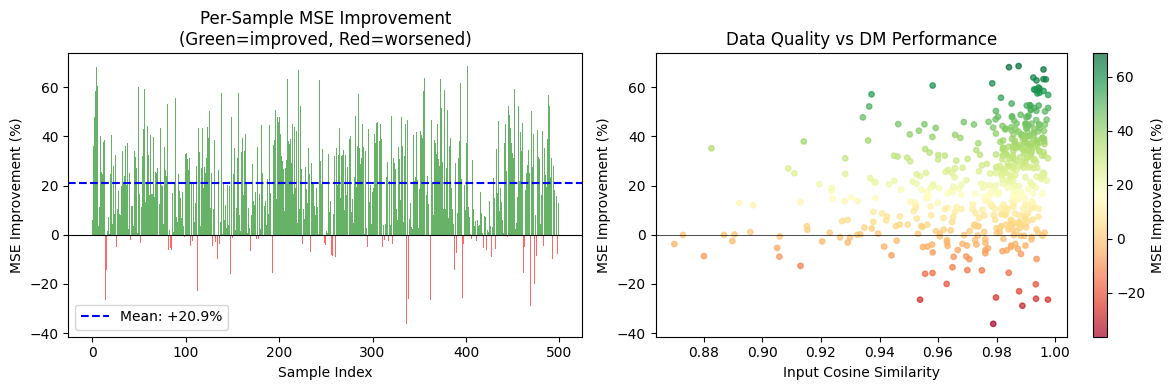

Saved: fig_improvement_v2.png


In [10]:
# ============================================================
# CELL 10 — Per-sample improvement plot
# ============================================================
mse_imp_arr = np.array(mse_imp)
cosines_arr = np.array([np.dot(noisy_raw[i], clean_raw[i]) /
                        (norm(noisy_raw[i]) * norm(clean_raw[i]) + 1e-8)
                        for i in range(len(noisy_raw))])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of improvement
ax = axes[0]
colors = ['green' if x > 0 else 'red' for x in mse_imp_arr]
ax.bar(range(len(mse_imp_arr)), mse_imp_arr, color=colors, alpha=0.6, width=1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(mse_imp_arr.mean(), color='blue', linestyle='--',
           label=f'Mean: {mse_imp_arr.mean():+.1f}%')
ax.set_xlabel('Sample Index')
ax.set_ylabel('MSE Improvement (%)')
ax.set_title('Per-Sample MSE Improvement\n(Green=improved, Red=worsened)')
ax.legend()

# Scatter: data quality vs improvement
ax = axes[1]
sc = ax.scatter(cosines_arr, mse_imp_arr,
                c=mse_imp_arr, cmap='RdYlGn', s=15, alpha=0.7)
plt.colorbar(sc, ax=ax, label='MSE Improvement (%)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Input Cosine Similarity')
ax.set_ylabel('MSE Improvement (%)')
ax.set_title('Data Quality vs DM Performance')

plt.tight_layout()
plt.savefig('fig_improvement_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_improvement_v2.png')

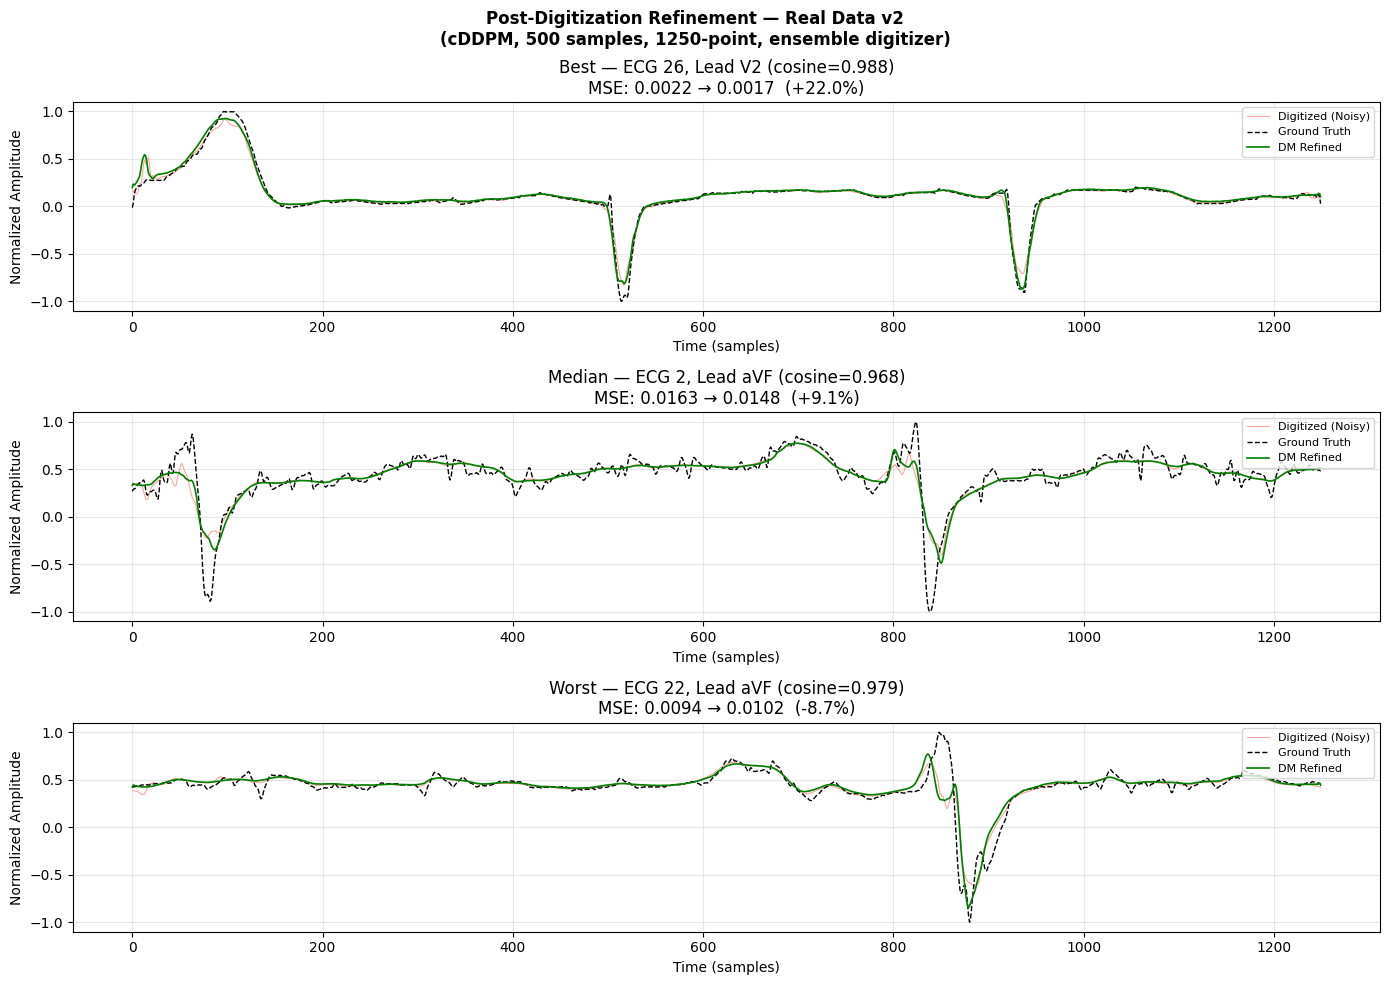

Saved: fig_signals_v2.png


In [11]:
# ============================================================
# CELL 11 — Signal plots (best / median / worst)
# ============================================================
sorted_by_imp = np.argsort(mse_imp_arr)[::-1]  # best first
plot_indices  = {
    'Best'   : sorted_by_imp[0],
    'Median' : sorted_by_imp[len(sorted_by_imp) // 2],
    'Worst'  : sorted_by_imp[-1],
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, (label, idx) in zip(axes, plot_indices.items()):
    cond    = torch.tensor(noisy_raw[idx]).unsqueeze(0).unsqueeze(0)
    refined = refine(model, cond, t_start=REFINE_STEPS)
    r_sig   = refined.cpu().numpy().flatten()
    n_sig   = noisy_raw[idx]
    c_sig   = clean_raw[idx]

    mb = metrics(n_sig, c_sig)
    ma = metrics(r_sig, c_sig)
    imp_val = (mb[0] - ma[0]) / (abs(mb[0]) + 1e-10) * 100

    # Get lead info from metadata
    lead_info = meta.iloc[idx]['lead'] if idx < len(meta) else '?'
    ecg_info  = meta.iloc[idx]['ecg_id'] if idx < len(meta) else '?'

    ax.plot(n_sig, color='salmon',  alpha=0.7, linewidth=0.8, label='Digitized (Noisy)')
    ax.plot(c_sig, color='black',   linewidth=1.0, linestyle='--', label='Ground Truth')
    ax.plot(r_sig, color='green',   linewidth=1.2, label='DM Refined')
    ax.set_title(f'{label} — ECG {ecg_info}, Lead {lead_info} '
                 f'(cosine={cosines_arr[idx]:.3f})\n'
                 f'MSE: {mb[0]:.4f} → {ma[0]:.4f}  ({imp_val:+.1f}%)')
    ax.set_xlabel('Time (samples)')
    ax.set_ylabel('Normalized Amplitude')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Post-Digitization Refinement — Real Data v2\n'
             '(cDDPM, 500 samples, 1250-point, ensemble digitizer)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_signals_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_signals_v2.png')

In [12]:
# ============================================================
# CELL 12 — Per-lead breakdown
# ============================================================
meta['mse_before'] = [before['mse'][i] for i in range(len(noisy_raw))]
meta['mse_after']  = [after['mse'][i]  for i in range(len(noisy_raw))]
meta['mse_imp_%']  = [(b - a) / (abs(b) + 1e-10) * 100
                       for b, a in zip(meta['mse_before'], meta['mse_after'])]

lead_summary = meta.groupby('lead').agg(
    count       = ('mse_imp_%', 'count'),
    cosine_mean = ('cosine',    'mean'),
    mse_imp_mean= ('mse_imp_%', 'mean'),
    mse_imp_min = ('mse_imp_%', 'min'),
    mse_imp_max = ('mse_imp_%', 'max'),
).round(2)

print('Per-lead MSE improvement:')
print(lead_summary.sort_values('mse_imp_mean', ascending=False).to_string())

meta.to_csv('results_per_sample.csv', index=False)
lead_summary.to_csv('results_per_lead.csv')
print('\nSaved: results_per_sample.csv, results_per_lead.csv')

Per-lead MSE improvement:
      count  cosine_mean  mse_imp_mean  mse_imp_min  mse_imp_max
lead                                                            
V2       59         0.98         30.44       -26.03        68.67
V1       66         0.98         28.06       -26.40        67.26
aVR      54         0.98         26.18        -8.34        63.24
V3       57         0.97         25.47       -22.99        63.97
aVL      58         0.97         20.62       -13.21        55.77
I        54         0.98         18.03        -8.97        57.80
aVF      52         0.97         16.58       -36.25        48.82
III      52         0.97         12.71       -14.49        44.91
II       23         0.96          9.22       -25.53        31.14
V4        7         0.94          6.45       -15.49        34.86
V5        8         0.97          0.90       -26.42        43.70
V6       10         0.98         -0.64       -20.13        19.10

Saved: results_per_sample.csv, results_per_lead.csv


In [14]:
# ============================================================
# CELL 13 — v1 vs v2 comparison summary (for presentation)
# ============================================================
print('=' * 65)
print('COMPARISON: v1 (120 samples) vs v2 (500 samples)')
print('=' * 65)
print(f'{"":<30} {"v1":>10} {"v2":>10}')
print('-' * 65)
print(f'{"Samples":<30} {"120":>10} {"500":>10}')
print(f'{"Signal length":<30} {"2500 (2x dup)":>10} {"1250 (real)":>10}')
print(f'{"Mean cosine similarity":<30} {"0.884":>10} {f"{cosines_arr.mean():.4f}":>10}')
print(f'{"Min cosine similarity":<30} {"−0.129":>10} {f"{cosines_arr.min():.4f}":>10}')
print(f'{"Normalization":<30} {"independent":>10} {"shared":>10}')
print(f'{"Digitizer":<30} {"color only":>10} {"ensemble":>10}')
print(f'{"MSE improvement":<30} {"−2.7%":>10} {f"{results[results.Metric=="MSE"]["Improvement (%)"].values[0]:+.1f}%":>10}')
print(f'{"Samples improved / total":<30} {"44/111":>10} {f"{improved}/{len(mse_imp)}":>10}')
print('=' * 65)
print('\nConclusion: data quality (not model) was the bottleneck.')
print(f'Best single sample improvement: {max(mse_imp):+.1f}%')

COMPARISON: v1 (120 samples) vs v2 (500 samples)
                                       v1         v2
-----------------------------------------------------------------
Samples                               120        500
Signal length                  2500 (2x dup) 1250 (real)
Mean cosine similarity              0.884     0.9735
Min cosine similarity              −0.129     0.8699
Normalization                  independent     shared
Digitizer                      color only   ensemble
MSE improvement                     −2.7%     +15.7%
Samples improved / total           44/111    429/500

Conclusion: data quality (not model) was the bottleneck.
Best single sample improvement: +68.7%
